# Missing events: HESE12 vs HESE pass2 v3

All topologies (track + cascade + double) are pooled into one dataset per source and compared by `(run_id, event_id)`.

The parquet datasets first get a `reco_energy > 60 TeV` cut. They also contain an extra year from `IC86_2022_GoodRunInfo.txt` (runs 136824–138614) which is absent from HESE12 by construction.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PLOT_DIR = 'missing_events_hese_12_13'
ENERGY_CUT = 60e3  # GeV

## Load and pool all topologies

In [26]:
HDF_BASE = '/data/ana/Diffuse/GlobalFit_Flavor/NNMFit_Datasets/data/HESE12/WithoutDeepCore'
PQ_BASE  = (
    '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/split'
    '/data_HESE_pass2_v3'
    '/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen'
    '/bdt1_0.333333_bdt2_0.366667_length_10'
)
GRI_2022 = '/data/exp/IceCube/2022/filtered/level2/IC86_2022_GoodRunInfo.txt'

# --- HESE12 ---
hdf_parts = []
for topo, folder, key in [
    ('track',  'data_HESE12_Tracks',        'dataset_HESE12_Tracks'),
    ('cascade','data_HESE12_Cascades',       'dataset_HESE12_Cascades'),
    ('double', 'data_HESE12_DoubleCascades', 'dataset_HESE12_DoubleCascades'),
]:
    df = pd.read_hdf(f'{HDF_BASE}/{folder}/{key}.hdf', key=key).reset_index()
    # level_0 = run_id, level_1 = event_id (same as the event_id column), level_2 = sub_event
    df = df.rename(columns={'level_0': 'run_id', 'level_2': 'sub_event'}).drop(columns='level_1')
    df['topology'] = topo
    hdf_parts.append(df)

hese12 = pd.concat(hdf_parts, ignore_index=True)

# --- parquet (after energy cut) ---
pq_parts = []
for topo in ['track', 'cascade', 'double']:
    df = pd.read_parquet(f'{PQ_BASE}/dataset_data_HESE_pass2_v3_{topo}.parquet').reset_index()
    df = df.rename(columns={'level_0': 'run_id', 'level_2': 'sub_event'}).drop(columns='level_1')
    df = df[df['reco_energy'] > ENERGY_CUT]
    df['topology'] = topo
    pq_parts.append(df)

pass2 = pd.concat(pq_parts, ignore_index=True)

# --- 2022 runs ---
runs_2022 = set(
    pd.read_csv(GRI_2022, sep=r'\s+', index_col=False, usecols=[0])['RunNum'].values
)

print(f'HESE12 total : {len(hese12)}')
print(f'pass2  total : {len(pass2)}  (after E > 60 TeV)')
print(f'2022 runs    : {min(runs_2022)} – {max(runs_2022)}')

HESE12 total : 97
pass2  total : 110  (after E > 60 TeV)
2022 runs    : 136824 – 138614


## Compare by (run_id, event_id)

In [27]:
ids_hese12 = set(zip(hese12['run_id'], hese12['event_id']))
ids_pass2  = set(zip(pass2['run_id'],  pass2['event_id']))

common     = ids_hese12 & ids_pass2
only_hese12 = ids_hese12 - ids_pass2
only_pass2  = ids_pass2  - ids_hese12

only_pass2_2022    = {(r, e) for r, e in only_pass2 if r in runs_2022}
only_pass2_non2022 = only_pass2 - only_pass2_2022

print(f'Common                        : {len(common)}')
print(f'Only in HESE12                : {len(only_hese12)}')
print(f'Only in pass2                 : {len(only_pass2)}')
print(f'  of which from 2022 runs     : {len(only_pass2_2022)}  (expected)')
print(f'  of which from earlier runs  : {len(only_pass2_non2022)}  (unexpected)')

Common                        : 95
Only in HESE12                : 2
Only in pass2                 : 15
  of which from 2022 runs     : 12  (expected)
  of which from earlier runs  : 3  (unexpected)


## Events only in HESE12

In [28]:
mask = hese12.apply(lambda r: (r['run_id'], r['event_id']) in only_hese12, axis=1)
df_only_hese12 = hese12[mask].sort_values('mjd')[['run_id','event_id','topology','mjd','reco_energy']]
display(df_only_hese12)

,run_id,event_id,topology,mjd,reco_energy
56,125914,75630389,cascade,57036.743775,70976.904502
5,127210,51027948,track,57363.442334,60806.979712


## HESE12-only events: are they in the full pass2 (no energy cut)?

In [29]:
# Load pass2 without energy cut for this check
pq_parts_full = []
for topo in ['track', 'cascade', 'double']:
    df = pd.read_parquet(f'{PQ_BASE}/dataset_data_HESE_pass2_v3_{topo}.parquet').reset_index()
    df = df.rename(columns={'level_0': 'run_id', 'level_2': 'sub_event'}).drop(columns='level_1')
    df['topology'] = topo
    pq_parts_full.append(df)
pass2_full = pd.concat(pq_parts_full, ignore_index=True)
ids_pass2_full = set(zip(pass2_full['run_id'], pass2_full['event_id']))

rows = []
for run, evt in sorted(only_hese12):
    h_row = hese12[(hese12['run_id'] == run) & (hese12['event_id'] == evt)].iloc[0]
    in_full = (run, evt) in ids_pass2_full
    if in_full:
        p_row = pass2_full[(pass2_full['run_id'] == run) & (pass2_full['event_id'] == evt)].iloc[0]
        pass2_topo = p_row['topology']
        pass2_energy = p_row['reco_energy']
    else:
        pass2_topo = '— absent —'
        pass2_energy = float('nan')
    rows.append({
        'run_id'         : run,
        'event_id'       : evt,
        'HESE12 topo'    : h_row['topology'],
        'HESE12 energy'  : h_row['reco_energy'],
        'in full pass2'  : in_full,
        'pass2 topo'     : pass2_topo,
        'pass2 energy'   : pass2_energy,
    })

display(pd.DataFrame(rows))

,run_id,event_id,HESE12 topo,HESE12 energy,in full pass2,pass2 topo,pass2 energy
0,125914,75630389,cascade,70976.904502,False,— absent —,NaN
1,127210,51027948,track,60806.979712,True,track,57664.093493


125914 75630389 had a QTot of 6000, and just dropped below threshold

## Events only in pass2 — non-2022 (unexpected)

In [36]:
mask = pass2.apply(lambda r: (r['run_id'], r['event_id']) in only_pass2_non2022, axis=1)
df_only_pass2_non2022 = pass2[mask].sort_values('mjd')[['run_id','event_id','topology','mjd','reco_energy']]
display(df_only_pass2_non2022)

,run_id,event_id,topology,mjd,reco_energy
4,121947,7181486,track,56352.807020,74496.777368
63,125826,470241,cascade,57027.490886,416499.030804
16,128672,38561326,track,57695.380221,83136.722946


## Unexpected pass2-only events: i3 file check

Check whether an i3 file exists in `/data/ana/Diffuse/GlobalFit_Flavor/taupede/data/Pass2/i3files/NoDeepCore/HESE12/Bfr/` for each unexpected event.

In [37]:
import glob

I3_BASE = '/data/ana/Diffuse/GlobalFit_Flavor/taupede/data/Pass2/i3files/NoDeepCore/HESE12/Bfr'

rows = []
for _, row in df_only_pass2_non2022.iterrows():
    run = row['run_id']
    mjd_int = int(row['mjd'])
    hits = glob.glob(f'{I3_BASE}/*/Run{run:08d}_MJD{mjd_int}*.i3*')
    rows.append({
        'run_id'    : run,
        'event_id'  : row['event_id'],
        'topology'  : row['topology'],
        'mjd'       : row['mjd'],
        'reco_energy': row['reco_energy'],
        'i3_found'  : len(hits) > 0,
        'i3_file'   : hits[0] if hits else '—',
    })

display(pd.DataFrame(rows))

,run_id,event_id,topology,mjd,reco_energy,i3_found,i3_file
0,121947,7181486,track,56352.807020,74496.777368,False,—
1,125826,470241,cascade,57027.490886,416499.030804,False,—
2,128672,38561326,track,57695.380221,83136.722946,True,/data/ana/Diffuse/GlobalFit_Flavor/taupede/dat...


## Events only in pass2 — 2022 runs (expected)

In [38]:
mask = pass2.apply(lambda r: (r['run_id'], r['event_id']) in only_pass2_2022, axis=1)
df_only_pass2_2022 = pass2[mask].sort_values('mjd')[['run_id','event_id','topology','mjd','reco_energy']]
display(df_only_pass2_2022)

,run_id,event_id,topology,mjd,reco_energy
35,137160,12005948,track,59868.307269,101232.515073
101,137167,67425471,cascade,59870.884719,63889.093898
102,137489,30229466,cascade,59942.956398,107491.037724
103,137527,43987982,cascade,59953.466797,62338.805831
36,137845,43811235,track,60051.836556,98998.283283
104,137891,38931474,cascade,60064.362531,66978.346548
105,137930,36941090,cascade,60075.239988,73436.089224
106,138035,55730330,cascade,60105.999717,78404.664837
107,138065,72143074,cascade,60116.080444,409014.982212
108,138069,72184188,cascade,60117.415932,64450.686608


## Plots

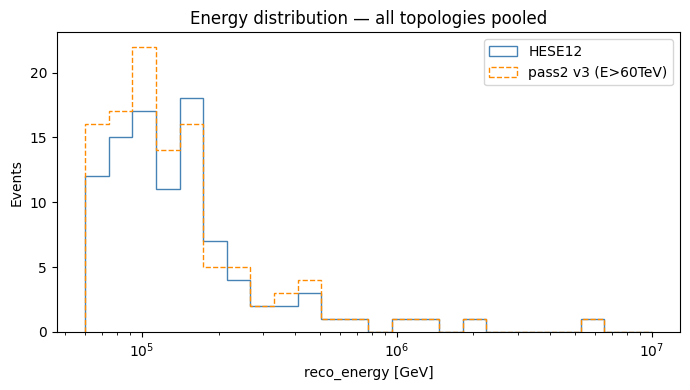

In [39]:
# Energy distribution — full datasets
bins_e = np.logspace(np.log10(60e3), np.log10(10e6), 25)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(hese12['reco_energy'], bins=bins_e, histtype='step', label='HESE12', color='steelblue', lw=2)
ax.hist(pass2['reco_energy'],  bins=bins_e, histtype='step', label='pass2 v3 (E>60TeV)', color='darkorange', lw=2, linestyle='--')
ax.set_xscale('log')
ax.set_xlabel('reco_energy [GeV]')
ax.set_ylabel('Events')
ax.set_title('Energy distribution — all topologies pooled')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/energy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

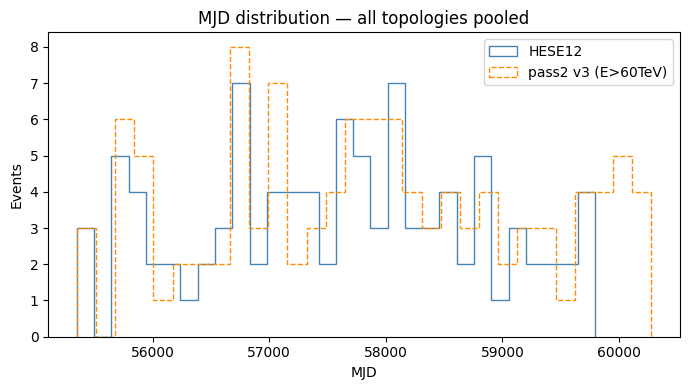

In [40]:
# MJD distribution — full datasets
bins_mjd = 30

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(hese12['mjd'], bins=bins_mjd, histtype='step', label='HESE12', color='steelblue', lw=2)
ax.hist(pass2['mjd'],  bins=bins_mjd, histtype='step', label='pass2 v3 (E>60TeV)', color='darkorange', lw=2, linestyle='--')
ax.set_xlabel('MJD')
ax.set_ylabel('Events')
ax.set_title('MJD distribution — all topologies pooled')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/mjd_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

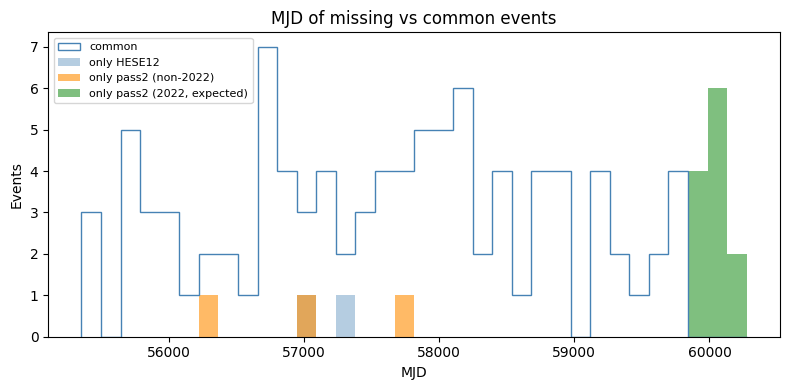

In [41]:
# MJD of missing events highlighted
fig, ax = plt.subplots(figsize=(8, 4))

mask_common_h = hese12.apply(lambda r: (r['run_id'], r['event_id']) in common, axis=1)
mask_common_p = pass2.apply(lambda r: (r['run_id'], r['event_id']) in common, axis=1)
mask_non2022  = pass2.apply(lambda r: (r['run_id'], r['event_id']) in only_pass2_non2022, axis=1)
mask_2022     = pass2.apply(lambda r: (r['run_id'], r['event_id']) in only_pass2_2022, axis=1)

bins_mjd = np.linspace(hese12['mjd'].min(), pass2['mjd'].max(), 35)

ax.hist(hese12.loc[mask_common_h, 'mjd'],  bins=bins_mjd, histtype='step', label='common', color='steelblue', lw=2)
ax.hist(hese12.loc[~mask_common_h, 'mjd'], bins=bins_mjd, histtype='stepfilled', label='only HESE12', color='steelblue', alpha=0.4)
ax.hist(pass2.loc[mask_non2022, 'mjd'],    bins=bins_mjd, histtype='stepfilled', label='only pass2 (non-2022)', color='darkorange', alpha=0.6)
ax.hist(pass2.loc[mask_2022, 'mjd'],       bins=bins_mjd, histtype='stepfilled', label='only pass2 (2022, expected)', color='green', alpha=0.5)

ax.set_xlabel('MJD')
ax.set_ylabel('Events')
ax.set_title('MJD of missing vs common events')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/mjd_missing_highlighted.png', dpi=150, bbox_inches='tight')
plt.show()